# Breakout (Atari 2600, 1978)

The [Atari 2600 (1977)](https://en.wikipedia.org/wiki/Atari_2600) was
the first hugely successful cartridge-based home console - the machine
that brought arcade games into people's living rooms. Atari itself had
been born out of *Pong* (1972), one of the first commercially successful
video games and arguably the one that launched the arcade industry.
Breakout is Pong's solo cousin: instead of volleying a ball against
another player, you send it into a wall of bricks.

<br>
<div style="display:flex; gap:48px; align-items:flex-end;">
<a title="Evan-Amos, Public domain, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Atari-2600-Wood-4Sw-Set.png"><img width="330" alt="Atari 2600" src="https://thumb.wikimedia.org/wikipedia/commons/thumb/0/02/Atari-2600-Wood-4Sw-Set.png/330px-Atari-2600-Wood-4Sw-Set.png?utm_source=commons.wikimedia.org&utm_campaign=index&utm_content=thumbnail"></a>
<img width="300" alt="Atari 2600 Breakout, 1978" src="images/breakout-420.png">
</div>
<br>
<br>

#### Jobs and Wozniak's Breakout
The 1976 arcade original has a [famous origin story](https://en.wikipedia.org/wiki/Breakout_%28video_game%29) - Atari co-founder Nolan Bushnell
tasked a young Steve Jobs with designing it as cheaply as possible (a
bonus for every chip he could shave off), and Jobs brought in his friend
Steve Wozniak, who built the prototype over four sleep-deprived nights.
Two years later, in 1978, Atari ported it to the 2600 as a home
cartridge, programmed by Brad Stewart - and it's that home version, shown
above on the right, not the arcade original, this notebook is modeled
after.

#### Breakout moment for AI
Breakout has one more claim to fame: it was among the Atari games
DeepMind used in 2013-2015 to demonstrate its [Deep Q-Network (DQN)](https://deepmind.google/blog/deep-reinforcement-learning/) - one
of the breakthrough moments of modern deep reinforcement learning,
learning to play directly from raw pixels with no knowledge of the
game's rules. Its Breakout agent stumbled onto a strategy no one taught
it: digging a tunnel up one side of the brick wall and sending the ball
bouncing around behind it, clearing whole rows at a time. It's one of
the most-cited examples of an AI discovering a genuinely non-obvious
strategy purely through trial and error. Here's DeepMind's own footage
of it:

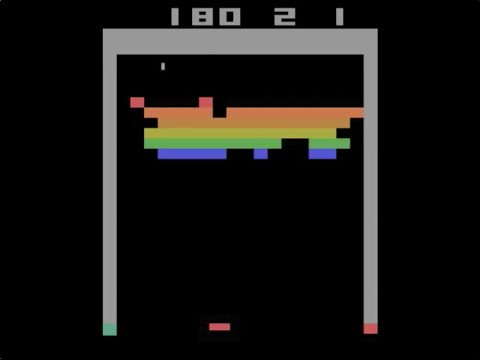

In [1]:
import IPython
IPython.display.YouTubeVideo('TmPfTpjtdgg')

#### Look Ma, no hands

Pause here for a moment, because this is the part I still find hard to
believe: every line of this notebook - the brick wall geometry, the
paddle physics, the hand-drawn pixel digit font, the square-wave
TIA-style sound - was written by
[Claude Code](https://claude.com/claude-code), Anthropic's AI coding
agent. Not one of my keystrokes.

It didn't get there by guessing. Claude Code already knew jupylet from
the inside: it had worked with me on the latest maintenance release,
reading the
[Jupylet Programmer's Reference Guide](https://jupylet.readthedocs.io/)
and the source code, finding and fixing bugs across the codebase. So it
came in knowing the actual API - `Sprite`, `Label`, `@app.event`,
`@app.run_me_every`, the sound synthesis primitives - and built on that
understanding the way a seasoned contributor would. Along the way it
found and fixed one more real bug in jupylet itself.

It wasn't one prompt and done, but rather a conversation. I'd look at the
result and say *"the paddle should be lower"*, *"the digits should be
5:3, not 5:4"*, *"make the canvas 12% taller"* - and each note was
read, understood, and acted on. It sampled the colors from a screenshot
of the original. When I asked about the sound, it went and worked out
how the real TIA chip generates its tones and reproduced that, rather
than settling for a beep. Round after round, the thing on my screen
crept closer to the cartridge I remember.

Think about what that is: a piece of software that, given a couple of
screenshots and a back-and-forth with a person, produced a faithful
replica of a 1978 game - and got it to look and sound right. Where DQN
once *learned to play* Breakout from raw pixels, here an AI *built*
Breakout from scratch - a neat echo of the moment this notebook opened
with.

---

Run this notebook and a game canvas should appear near the bottom. Click
it once to bring it into focus, then use the arrow keys or A/D to move
the paddle - or just move your mouse left and right over the canvas,
which mimics the original's paddle controller (a knob whose absolute
position set the paddle's position directly).

In [2]:
import math
import sys
import os

import numpy as np

In [3]:
sys.path.insert(0, os.path.abspath('./..'))

In [4]:
from jupylet.app import App
from jupylet.state import State
from jupylet.sprite import Sprite

from jupylet.audio.sound import GatedSound, Envelope, Oscillator
from jupylet.audio.note import note2key

In [5]:
app = App(width=512, height=382)  # ~3:2, matching a reference screenshot

### 1. Layout

`unit` is the height of one brick row. Everything below is measured as a
multiple of it (or of `wall_unit`, a second, independent unit the walls
are measured in), so bumping `unit` up or down changes the whole look of
the game at once instead of needing dozens of separate edits.

In [6]:
wall_unit = 12.8  # base size the wall width is measured in
SIDE = 2 * wall_unit  # thickness of the left/right walls

In [7]:
unit = wall_unit * 0.9  # thickness of the ceiling and paddle, and one brick row's base size
CEIL_H = round(2*unit)  # rounded once here so every position derived from it lines up exactly, with no gap
top_gap = 3*unit  # empty black space between the ceiling and the top brick row

In [8]:
HUD_H = 3*unit  # height of the black strip above the ceiling, where the scoreboard digits live

In [9]:
PLAY_TOP = round(app.height - HUD_H - CEIL_H)  # y of the ceiling's underside - the ball bounces here
PLAY_LEFT = SIDE
PLAY_RIGHT = app.width - SIDE

In [10]:
COLS, ROWS = 16, 6  # the brick grid
BRICKW, BRICKH = (app.width - 2*SIDE) / COLS, unit * 1.10  # bricks are a bit thicker than the shared unit

In [11]:
ty = PLAY_TOP - top_gap  # y of the top brick row's top edge
bricks_bottom = ty - ROWS * BRICKH  # y of the bottom brick row's bottom edge - the open play area starts here

In [12]:
PADW, PADH = 56, unit / 2  # paddle width and thickness
BALLS = round(PADH)  # the ball is a square the same thickness as the paddle

### 2. Colors

In [13]:
FRAME_COLOR = '#808280'  # the walls, ceiling, and scoreboard digits
TAN = '#cc9955'  # the paddle and ball

In [14]:
# brick rows, top to bottom - sampled by eye from a reference screenshot, so
# feel free to tweak the hex values.
row_color = ['#3e8c58', '#70b28a', '#c4566c', '#58a8b2', '#d4ac5c', '#5a62d0']

### 3. Game feel

Tweak these to change how the game plays.

In [15]:
STARTING_LIVES = 3

In [16]:
PADDLE_SPEED = 480  # pixels per second, when moved by keyboard
PADDLE_DEFLECT_ANGLE = 60  # degrees - how sharply the ball bounces off the paddle's edges

In [17]:
BALL_START_VX, BALL_START_VY = 162, -198  # pixels per second, at the start of each ball

In [18]:
# where each ball starts: just below the bottom brick row, near the right
# wall - as if it had just been thrown in - but inset by half the ball's own
# size so it's fully inside the court rather than drawn over the wall.
BALL_START_X = PLAY_RIGHT - BALLS/2
BALL_START_Y = bricks_bottom - BALLS

### 4. Sound

Real Atari 2600 games have no hardware envelope generator - a game just
holds a flat volume then snaps it off, instead of fading out like a synth
does. `Blip` copies that: near-instant on, held flat, then a very short
(not instant, to avoid a click) release, explicitly timed rather than
left to decay on its own.

In [19]:
class Blip(GatedSound):
    """A short square-wave pulse, like the original's beeps and bloops."""

    def __init__(self, amp=0.3, pan=0., hold=0.16):
        super().__init__(amp=amp, pan=pan)
        self.env0 = Envelope(0.001, 0.002, 1., 0.02, linear=True)
        self.osc0 = Oscillator('square')
        self.hold = hold  # how long the note stays on, in seconds

    def play(self, note=None, **kwargs):
        super().play(note, **kwargs)
        self.gate.close(dt=self.hold)

    def forward(self):
        self.osc0.freq = self.freq
        g0 = self.gate()
        e0 = self.env0(g0)
        o0 = self.osc0()
        return o0 * e0

In [20]:
blip = Blip()

In [21]:
WALL_NOTE = note2key('C6')   # walls, ceiling, and a new ball's onset
PADDLE_NOTE = note2key('D5')

In [22]:
# brick rows, top to bottom (the original numbering was bottom to top, so
# this list is reversed from how it was first given). The top row's note
# wasn't given, so C6 (matching the wall/onset tone) is a guess.
row_notes = [note2key(n) for n in ['C6', 'G4', 'D#4', 'C#4', 'A#3', 'F3']]

### 5. Sprites

A `Sprite` normally loads an image file; here we hand it a plain numpy
array instead - a solid block of white pixels - and let `color=` tint
it. That's how every flat-colored shape in this game (walls, bricks,
paddle, ball, digits) is made, with no image files at all.

In [23]:
paddle = Sprite(np.ones((round(PADH), round(PADW))) * 255, x=app.width/2, y=BRICKH + PADH/2, color=TAN)
ball = Sprite(np.ones((BALLS, BALLS)) * 255, x=BALL_START_X, y=BALL_START_Y, color=TAN)

In [24]:
# the walls - open at the bottom, like the original.
frame_top = Sprite(np.ones((CEIL_H, app.width)) * 255, x=app.width/2, y=PLAY_TOP + CEIL_H/2, color=FRAME_COLOR)
frame_left = Sprite(np.ones((PLAY_TOP, round(SIDE))) * 255, x=SIDE/2, y=PLAY_TOP/2, color=FRAME_COLOR)
frame_right = Sprite(np.ones((PLAY_TOP, round(SIDE))) * 255, x=app.width - SIDE/2, y=PLAY_TOP/2, color=FRAME_COLOR)

A blocky pixel digit font, in the spirit of the original console's
scoreboard - hand drawn, not lifted from an authentic ROM font. Each
digit is a 3x5 grid of cells, stretched to a 2:1 (w:h) overall shape.

In [25]:
DIGITS = {
    '0': ['111', '101', '101', '101', '111'],
    '1': ['010', '010', '010', '010', '010'],
    '2': ['111', '001', '111', '100', '111'],
    '3': ['111', '001', '111', '001', '111'],
    '4': ['101', '101', '111', '001', '001'],
    '5': ['111', '100', '111', '001', '111'],
    '6': ['111', '100', '111', '101', '111'],
    '7': ['111', '001', '001', '001', '001'],
    '8': ['111', '101', '111', '101', '111'],
    '9': ['111', '101', '111', '001', '111'],
}

In [26]:
DIGIT_H = CEIL_H * 0.85  # a bit less than the ceiling's thickness
DIGIT_W = DIGIT_H * 2
DIGIT_GAP = DIGIT_W / 3  # space between two neighboring digits

BLOCK_W, BLOCK_H = DIGIT_W / 3, DIGIT_H / 5  # size of one "pixel" of the font

In [27]:
def digits_image(s):
    """Draw a string of digits (e.g. '007') as a single black-and-white image."""

    w = len(s) * (DIGIT_W + DIGIT_GAP) - DIGIT_GAP
    img = np.zeros((round(DIGIT_H), round(w)))

    for i, c in enumerate(s):
        x0 = i * (DIGIT_W + DIGIT_GAP)

        for row, bits in enumerate(DIGITS[c]):
            for col, bit in enumerate(bits):
                if bit == '1':
                    y0, y1 = round(row*BLOCK_H), round((row+1)*BLOCK_H)
                    x1, x2 = round(x0 + col*BLOCK_W), round(x0 + (col+1)*BLOCK_W)
                    img[y0:y1, x1:x2] = 255

    return img

In [28]:
# point value of each row, top to bottom - just a made-up descending scale,
# not a documented value from the original.
row_points = [6, 5, 4, 3, 2, 1]

brick_img = np.ones((round(BRICKH), round(BRICKW))) * 255
bricks = []

for row in range(ROWS):
    for col in range(COLS):
        brick = Sprite(
            brick_img,
            x=SIDE + col * BRICKW + BRICKW / 2,
            y=ty - row * BRICKH - BRICKH / 2,
            color=row_color[row],
        )
        brick.points = row_points[row]
        brick.note = row_notes[row]
        bricks.append(brick)

In [29]:
# score and lives sit side by side, centered under the ceiling, separated by
# the width of an empty digit (including its two flanking gaps): 5/3 of a
# digit's width.
group_gap = DIGIT_W * 5 / 3

score = Sprite(digits_image('000'), x=app.width/2, y=app.height - HUD_H/2, anchor_x='right', color=FRAME_COLOR, collisions=False)
lives = Sprite(digits_image(str(STARTING_LIVES)), x=app.width/2 + group_gap, y=app.height - HUD_H/2, anchor_x='left', color=FRAME_COLOR, collisions=False)

Draw everything to the canvas. The order matters here - sprites drawn
later appear on top of ones drawn earlier.

In [30]:
@app.event
def render(ct, dt):

    app.window.clear(color='black')

    frame_top.draw()
    frame_left.draw()
    frame_right.draw()

    for brick in bricks:
        brick.draw()

    score.draw()
    lives.draw()

    paddle.draw()
    ball.draw()

### 6. Game loop

Everything below either sets up the game's starting state, or is a
function that runs every frame or on a keyboard/mouse event: reading
input, moving the paddle, moving the ball, and checking every kind of
collision it can have.

In [31]:
state = State(
    left=False,
    right=False,

    playing=True,

    score=0,
    lives=STARTING_LIVES,

    bvx=BALL_START_VX,
    bvy=BALL_START_VY,
)

In [32]:
@app.event
def key_event(key, action, modifiers):
    """Track which arrow/WASD keys are currently held down."""

    keys = app.window.keys
    pressed = action != keys.ACTION_RELEASE

    if key in (keys.LEFT, keys.A):
        state.left = pressed

    if key in (keys.RIGHT, keys.D):
        state.right = pressed

In [33]:
@app.event
def mouse_position_event(x, y, dx, dy):
    # mimics the original's paddle controller - a potentiometer wheel whose
    # absolute position set the paddle's position directly.
    paddle.x = max(PLAY_LEFT + PADW/2, min(PLAY_RIGHT - PADW/2, x))

In [34]:
@app.run_me_every(1/120)
def update_paddle(ct, dt):
    """Move the paddle from held keys, then keep it inside the walls."""

    if state.left:
        paddle.x -= dt * PADDLE_SPEED

    if state.right:
        paddle.x += dt * PADDLE_SPEED

    paddle.x = max(PLAY_LEFT + PADW/2, min(PLAY_RIGHT - PADW/2, paddle.x))

In [35]:
@app.run_me_every(1/60)
def update_ball(ct, dt):
    """Move the ball, then check every kind of collision it can have:
    the walls, the paddle, the bricks, and missing the paddle entirely."""

    if not state.playing:
        return

    ball.x += state.bvx * dt
    ball.y += state.bvy * dt

    if ball.left <= PLAY_LEFT:
        ball.x -= ball.left - PLAY_LEFT
        state.bvx = -state.bvx
        blip.play(note=WALL_NOTE)

    if ball.right >= PLAY_RIGHT:
        ball.x -= ball.right - PLAY_RIGHT
        state.bvx = -state.bvx
        blip.play(note=WALL_NOTE)

    if ball.top >= PLAY_TOP:
        ball.y -= ball.top - PLAY_TOP
        state.bvy = -state.bvy
        blip.play(note=WALL_NOTE)

    # bounce off the paddle - hitting off-center sends the ball off at a
    # sharper angle, same as the original; hitting dead center keeps it
    # close to vertical.
    if state.bvy < 0 and ball.bottom <= paddle.top and paddle.left <= ball.x <= paddle.right:
        ball.y -= ball.bottom - paddle.top

        speed = (state.bvx ** 2 + state.bvy ** 2) ** 0.5
        offset = max(-1, min(1, (ball.x - paddle.x) / (PADW / 2)))
        angle = math.radians(offset * PADDLE_DEFLECT_ANGLE)

        state.bvx = speed * math.sin(angle)
        state.bvy = speed * math.cos(angle)

        blip.play(note=PADDLE_NOTE)

    for brick in bricks:
        if brick.opacity <= 0:
            continue

        if ball.right >= brick.left and ball.left <= brick.right and ball.top >= brick.bottom and ball.bottom <= brick.top:
            brick.opacity = 0

            # whichever axis the ball overlaps the brick by less is the
            # side it just came through - bounce that axis, not always
            # vertically, so a hit on a brick's left/right edge bounces
            # the ball sideways instead of flipping it top-down.
            overlap_x = min(ball.right, brick.right) - max(ball.left, brick.left)
            overlap_y = min(ball.top, brick.top) - max(ball.bottom, brick.bottom)

            if overlap_x < overlap_y:
                ball.x += -overlap_x if ball.x < brick.x else overlap_x
                state.bvx = -state.bvx
            else:
                ball.y += -overlap_y if ball.y < brick.y else overlap_y
                state.bvy = -state.bvy

            state.score += brick.points
            score.image = digits_image(str(state.score).zfill(3))

            blip.play(note=brick.note)
            break

    if all(brick.opacity <= 0 for brick in bricks):
        state.playing = False  # the original has no "you win" message, it just stops.

    # ball got past the paddle.
    if ball.top < 0:
        state.lives -= 1
        lives.image = digits_image(str(state.lives))

        if state.lives <= 0:
            state.playing = False  # ditto for "game over" - no message, and the paddle stays controllable.
        else:
            ball.x, ball.y = BALL_START_X, BALL_START_Y
            state.bvx, state.bvy = BALL_START_VX, BALL_START_VY
            blip.play(note=WALL_NOTE)

And finally, start the game:

In [36]:
app.run()

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x0…